In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
adata = sc.read_h5ad("data/processed/aging_data_qc.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 2638 × 32738
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p'


In [5]:
print(adata.obs.columns.tolist())

['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt']


In [6]:
adata.obs.head()

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
index,,,,,,,,,,,
AAACATACAACCAC-1,781,6.661855,2421.0,7.792349,47.748864,63.279637,74.969021,88.393226,73.0,4.304065,3.015283
AAACATTGAGCTAC-1,1352,7.210080,4903.0,8.497807,45.502753,61.023863,71.813176,82.622884,186.0,5.231109,3.793596
AAACATTGATCAGC-1,1131,7.031741,3149.0,8.055158,41.314703,53.794856,65.449349,79.961893,28.0,3.367296,0.889171
AAACCGTGCTTCCG-1,960,6.867974,2639.0,7.878534,39.029936,52.898825,66.691929,82.569155,46.0,3.850147,1.743085
AAACCGTGTATGCG-1,522,6.259581,981.0,6.889591,44.852192,55.657492,67.176351,97.757390,12.0,2.564949,1.223242


In [7]:
sc.tl.pca(adata)

In [8]:
print(adata.obsm["X_pca"].shape)

(2638, 50)


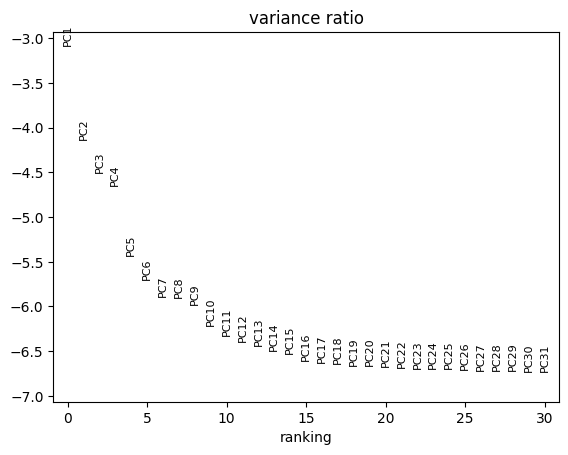

In [9]:
sc.pl.pca_variance_ratio(
    adata,
    log=True
)

In [10]:
sc.pp.neighbors(
    adata,
    n_neighbors=15,
    n_pcs=30
)

/Users/palaksharma/aging-clock-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 1.0 MB/s  0:00:0073.0 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 363.3 kB/s  0:00:054.0 kB/s eta 0:00:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]


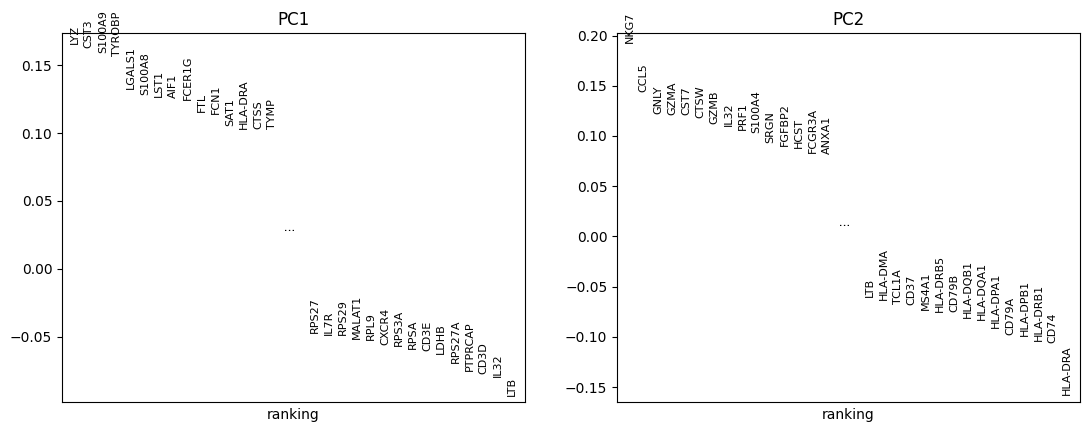

In [13]:
sc.pl.pca_loadings(adata, components=(1, 2), include_lowest=True)

In [17]:
sc.pp.neighbors(
    adata,
    n_neighbors=15,
    n_pcs=30
) 
print ("graph done")

graph done


#The neighbor graph connects transcriptionally similar cells.

In [18]:
sc.tl.umap(adata)

In [21]:
!pip install leidenalg igraph

In [22]:
sc.tl.leiden(
    adata,
    resolution=0.5
)

/var/folders/ys/f4dnpd295d91m1ctpdbcgl3w0000gn/T/ipykernel_2697/1038046097.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


In [23]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

#UMAP helps visualize whether cells form distinct groups based on gene expression.

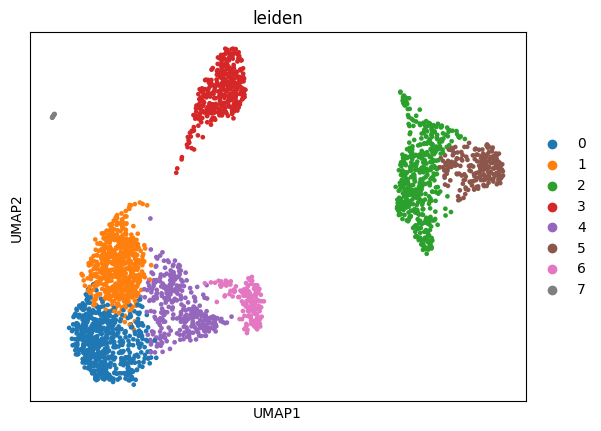

In [24]:
sc.pl.umap(
    adata,
    color="leiden"
)

#These clusters can correspond to biological cell states or cell types and help reveal structure within the aging dataset.

In [25]:
print(adata.obs.columns.tolist())

['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden']


In [26]:
print(adata)

AnnData object with n_obs × n_vars = 2638 × 32738
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


In [27]:
print(adata.uns.keys())

dict_keys(['log1p', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors'])


In [28]:
print(adata.obs.head())

                  n_genes_by_counts  log1p_n_genes_by_counts  total_counts  \
index                                                                        
AAACATACAACCAC-1                781                 6.661855        2421.0   
AAACATTGAGCTAC-1               1352                 7.210080        4903.0   
AAACATTGATCAGC-1               1131                 7.031741        3149.0   
AAACCGTGCTTCCG-1                960                 6.867974        2639.0   
AAACCGTGTATGCG-1                522                 6.259581         981.0   

                  log1p_total_counts  pct_counts_in_top_50_genes  \
index                                                              
AAACATACAACCAC-1            7.792349                   47.748864   
AAACATTGAGCTAC-1            8.497807                   45.502753   
AAACATTGATCAGC-1            8.055158                   41.314703   
AAACCGTGCTTCCG-1            7.878534                   39.029936   
AAACCGTGTATGCG-1            6.889591         

#PCA was used to reduce the gene expression matrix into major axes of variation.